# `evap_cool` — equilibrium thermodynamics

This notebook visualises the post-processed thermodynamics produced by
`evap_cool.post_processing`: the equilibrium state functions
$\Omega$, $S$, $P$, $H$, $F$, $G$ and the thermal coefficients
$C_V$, $C_P$, $\kappa_T$, $B_P$, evaluated at every step of the cooling
trajectory.

For each trap (box, quadrupole, oscillator) we plot two figures:

1. **State functions** — a 2×3 grid of $\Omega$, $S$, $P$, $H$, $F$, $G$
   vs sample temperature $T$.
2. **Thermal coefficients** — a 2×2 grid of $C_V$, $C_P$, $\kappa_T$,
   $B_P$ vs $T$.

Bosons (green) and fermions (red) are overlaid on every panel.

> **Prerequisite.** Run `evap_cool_usage.ipynb` first to produce the
> `*_thermo.json` files this notebook reads. The cells below pick up the
> most recent session under `runs/` and skip any trap whose thermo file
> isn't there yet (e.g. the box, until its $s = 3/2$ equilibrium
> derivation is paper-validated).


## Setup

We import the new plotting helpers from `evap_cool.plots`:

- `plot_state_functions(T_b, thermo_b, T_f, thermo_f, trap_name, ...)`
- `plot_thermal_coefficients(T_b, thermo_b, T_f, thermo_f, trap_name, ...)`

Both default to log-log axes. Quantities that can be negative
($\Omega$, $F$, $G$) are plotted in absolute value with the title
showing $|\cdot|$ — set `log_y=False` if you'd rather see the signed
values on a linear scale.


In [1]:
import matplotlib.pyplot as plt

from evap_cool import (
    load_run, load_thermodynamics,
    list_sessions, list_runs,
    plot_state_functions, plot_thermal_coefficients,
)


## Locate the most recent session

`list_sessions("runs")` returns every `runs/<date>/<time>/` folder
chronologically; we pick the latest. Override `session` manually if you
want to plot an older run.


In [2]:
sessions = list_sessions("runs")
if not sessions:
    raise RuntimeError(
        "No sessions found under runs/. "
        "Run evap_cool_usage.ipynb first to generate the thermo files."
    )

session = sessions[-1]
print(f"Using session : {session}")
print(f"Files present :")
for p in list_runs(session):
    print(f"  {p.relative_to(session)}")


Using session : runs\2026-05-06\00h51m34s
Files present :
  box_bosons.json
  box_fermions.json
  box_mb.json
  oscillator_bosons.json
  oscillator_bosons_thermo.json
  oscillator_fermions.json
  oscillator_fermions_thermo.json
  oscillator_mb.json
  quadrupole_bosons.json
  quadrupole_bosons_thermo.json
  quadrupole_fermions.json
  quadrupole_fermions_thermo.json
  quadrupole_mb.json


## Helper: load one trap's source + thermo files

For a given trap label (e.g. `"box"`, `"quadrupole"`, `"oscillator"`) we
need four files in the session folder:

- `<trap>_bosons.json`  + `<trap>_bosons_thermo.json`
- `<trap>_fermions.json` + `<trap>_fermions_thermo.json`

The helper returns `(T_b, thermo_b, T_f, thermo_f)` ready to feed into
the plot functions, or `None` if any file is missing (so we can
gracefully skip traps without post-processed data).


In [3]:
def load_thermo_pair(session, trap_label):
    """Return (T_b, thermo_b, T_f, thermo_f) for one trap, or None."""
    needed = {
        "src_b": session / f"{trap_label}_bosons.json",
        "thr_b": session / f"{trap_label}_bosons_thermo.json",
        "src_f": session / f"{trap_label}_fermions.json",
        "thr_f": session / f"{trap_label}_fermions_thermo.json",
    }
    missing = [p.name for p in needed.values() if not p.exists()]
    if missing:
        print(f"  [skip] {trap_label}: missing {missing}")
        return None

    src_b = load_run(needed["src_b"])
    src_f = load_run(needed["src_f"])
    thr_b = load_thermodynamics(needed["thr_b"])
    thr_f = load_thermodynamics(needed["thr_f"])

    T_b      = src_b["results"]["T"]
    T_f      = src_f["results"]["T"]
    thermo_b = thr_b["results"]
    thermo_f = thr_f["results"]
    return T_b, thermo_b, T_f, thermo_f


def units_for(trap_label):
    """Energy-unit string per trap. Box runs in SI (J); quadrupole and
    oscillator default to eV."""
    return "J" if trap_label == "box" else "eV"


## 1. Box trap — $s = 3/2$

The box uses SI units, so all energy-bearing axes are in J. (If the
$s = 3/2$ equilibrium derivation hasn't been validated yet and the
post-processing call was skipped in the upstream notebook, this section
will report the missing files and silently move on.)


In [4]:
data = load_thermo_pair(session, "box")
if data is not None:
    T_b, thermo_b, T_f, thermo_f = data
    fig_box_state = plot_state_functions(
        T_b, thermo_b, T_f, thermo_f,
        trap_name="Box",
        units_energy=units_for("box"),
    )
    plt.show()


  [skip] box: missing ['box_bosons_thermo.json', 'box_fermions_thermo.json']


In [5]:
if data is not None:
    fig_box_coef = plot_thermal_coefficients(
        T_b, thermo_b, T_f, thermo_f,
        trap_name="Box",
        units_energy=units_for("box"),
    )
    plt.show()


## 2. Quadrupole trap — $s = 9/2$

Linear potential $U(r) = \bar A\, r$. eV units (energy axes in eV).


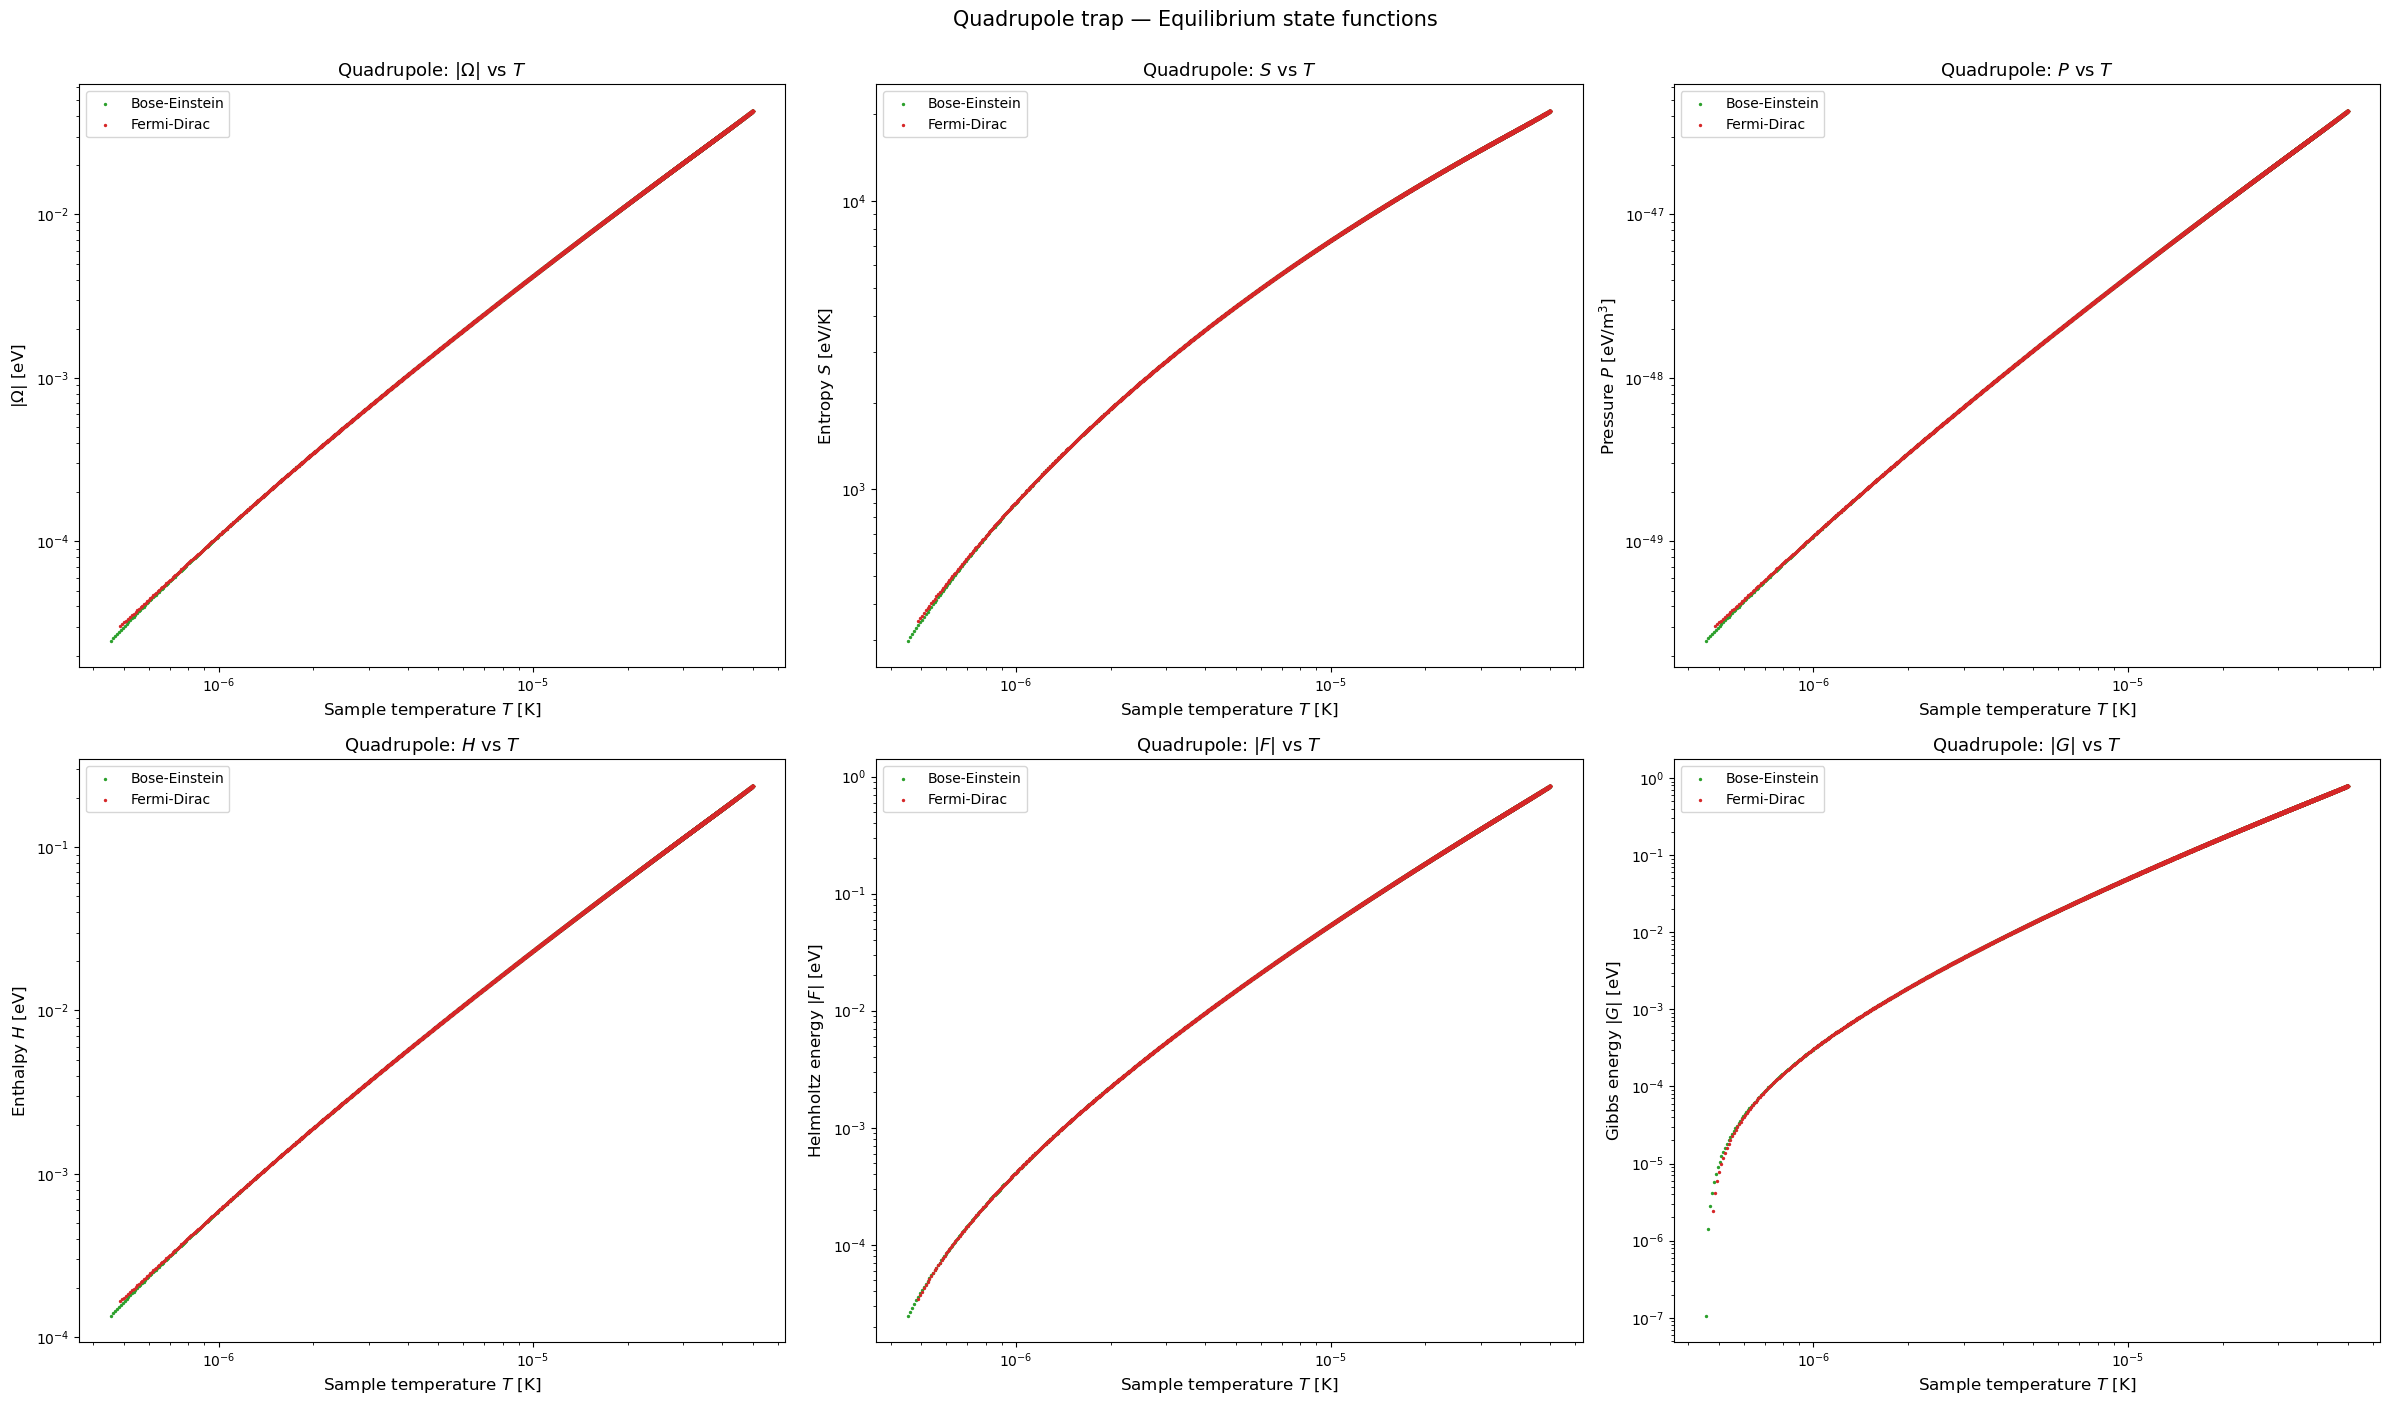

In [6]:
data = load_thermo_pair(session, "quadrupole")
if data is not None:
    T_b, thermo_b, T_f, thermo_f = data
    fig_quad_state = plot_state_functions(
        T_b, thermo_b, T_f, thermo_f,
        trap_name="Quadrupole",
        units_energy=units_for("quadrupole"),
    )
    plt.show()


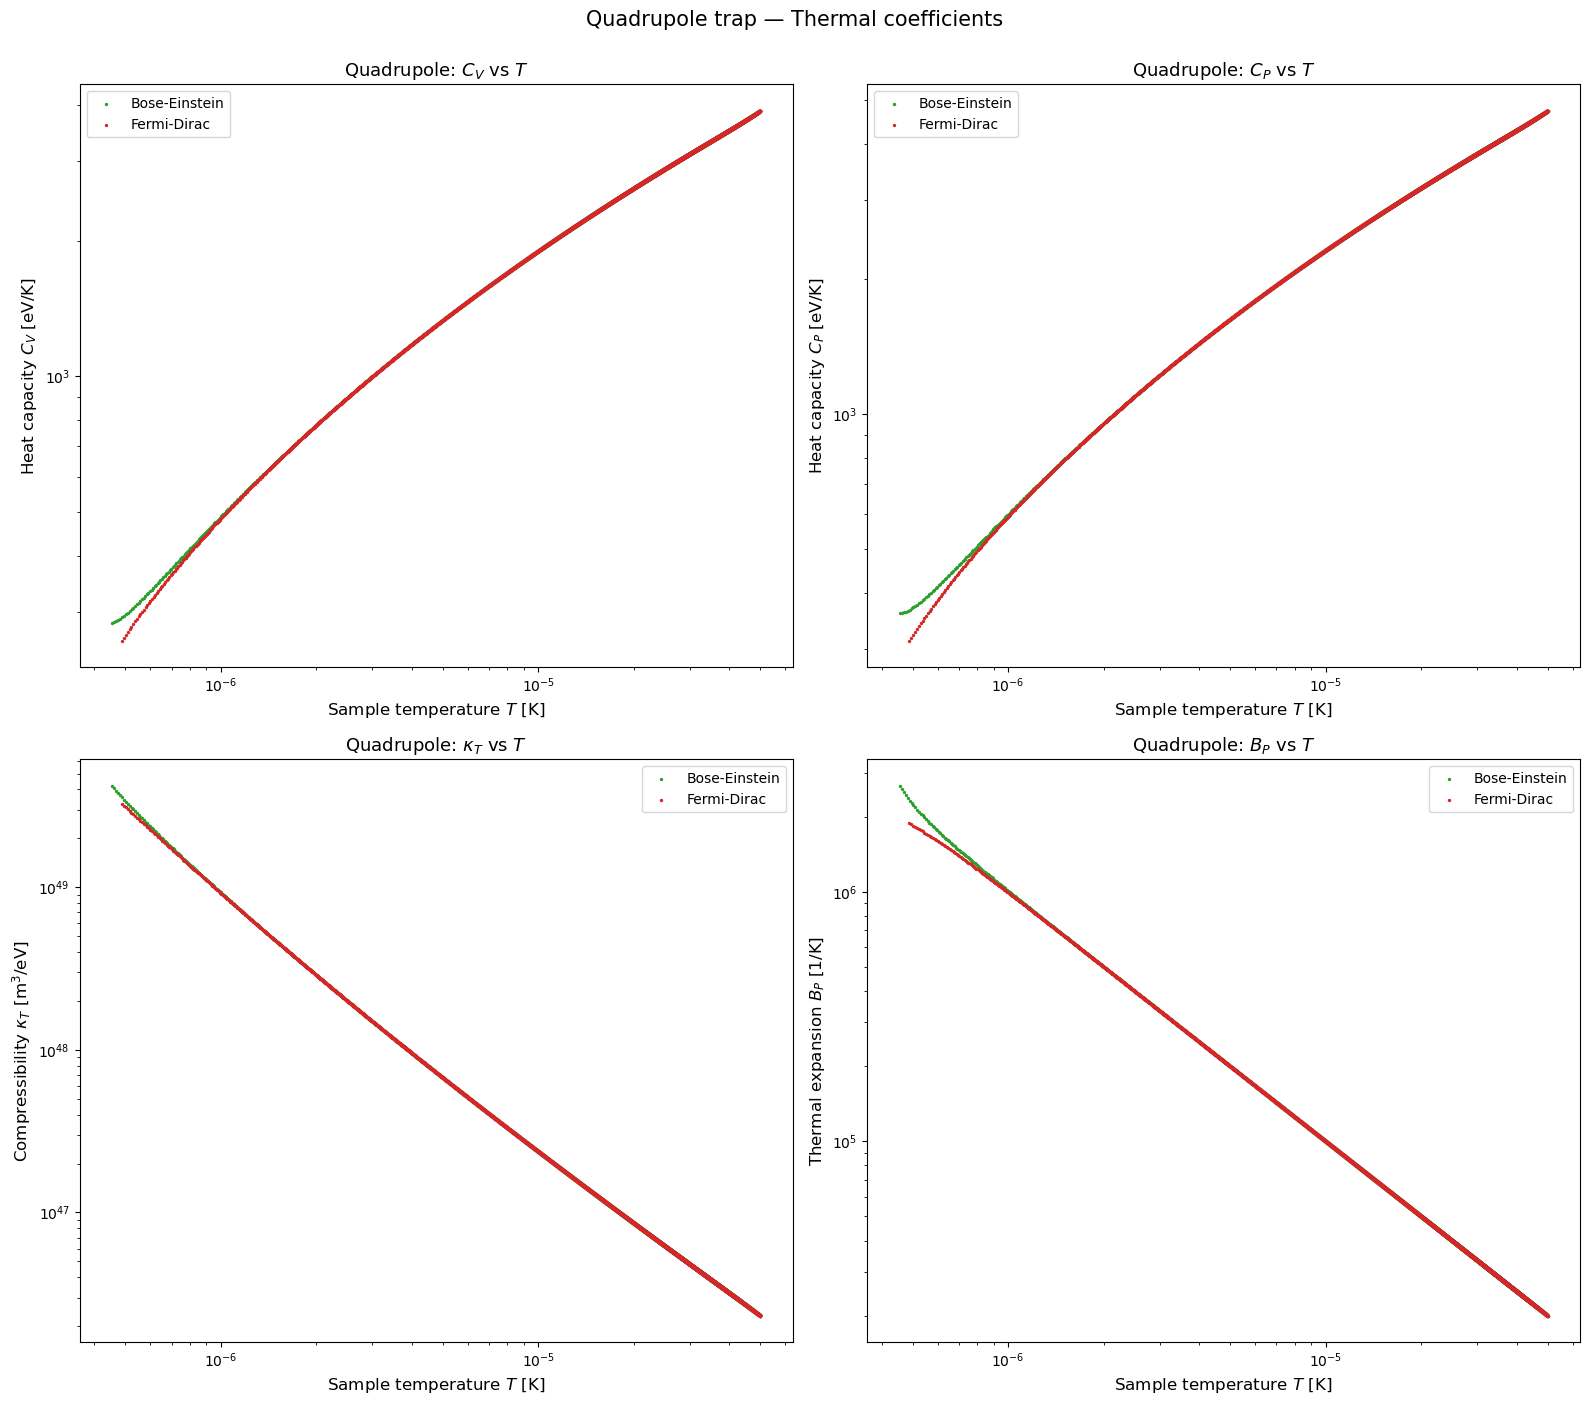

In [7]:
if data is not None:
    fig_quad_coef = plot_thermal_coefficients(
        T_b, thermo_b, T_f, thermo_f,
        trap_name="Quadrupole",
        units_energy=units_for("quadrupole"),
    )
    plt.show()


## 3. Harmonic oscillator trap — $s = 3$

Isotropic 3D oscillator $U(r) = \tfrac{1}{2} m \omega^2 r^2$. eV units.


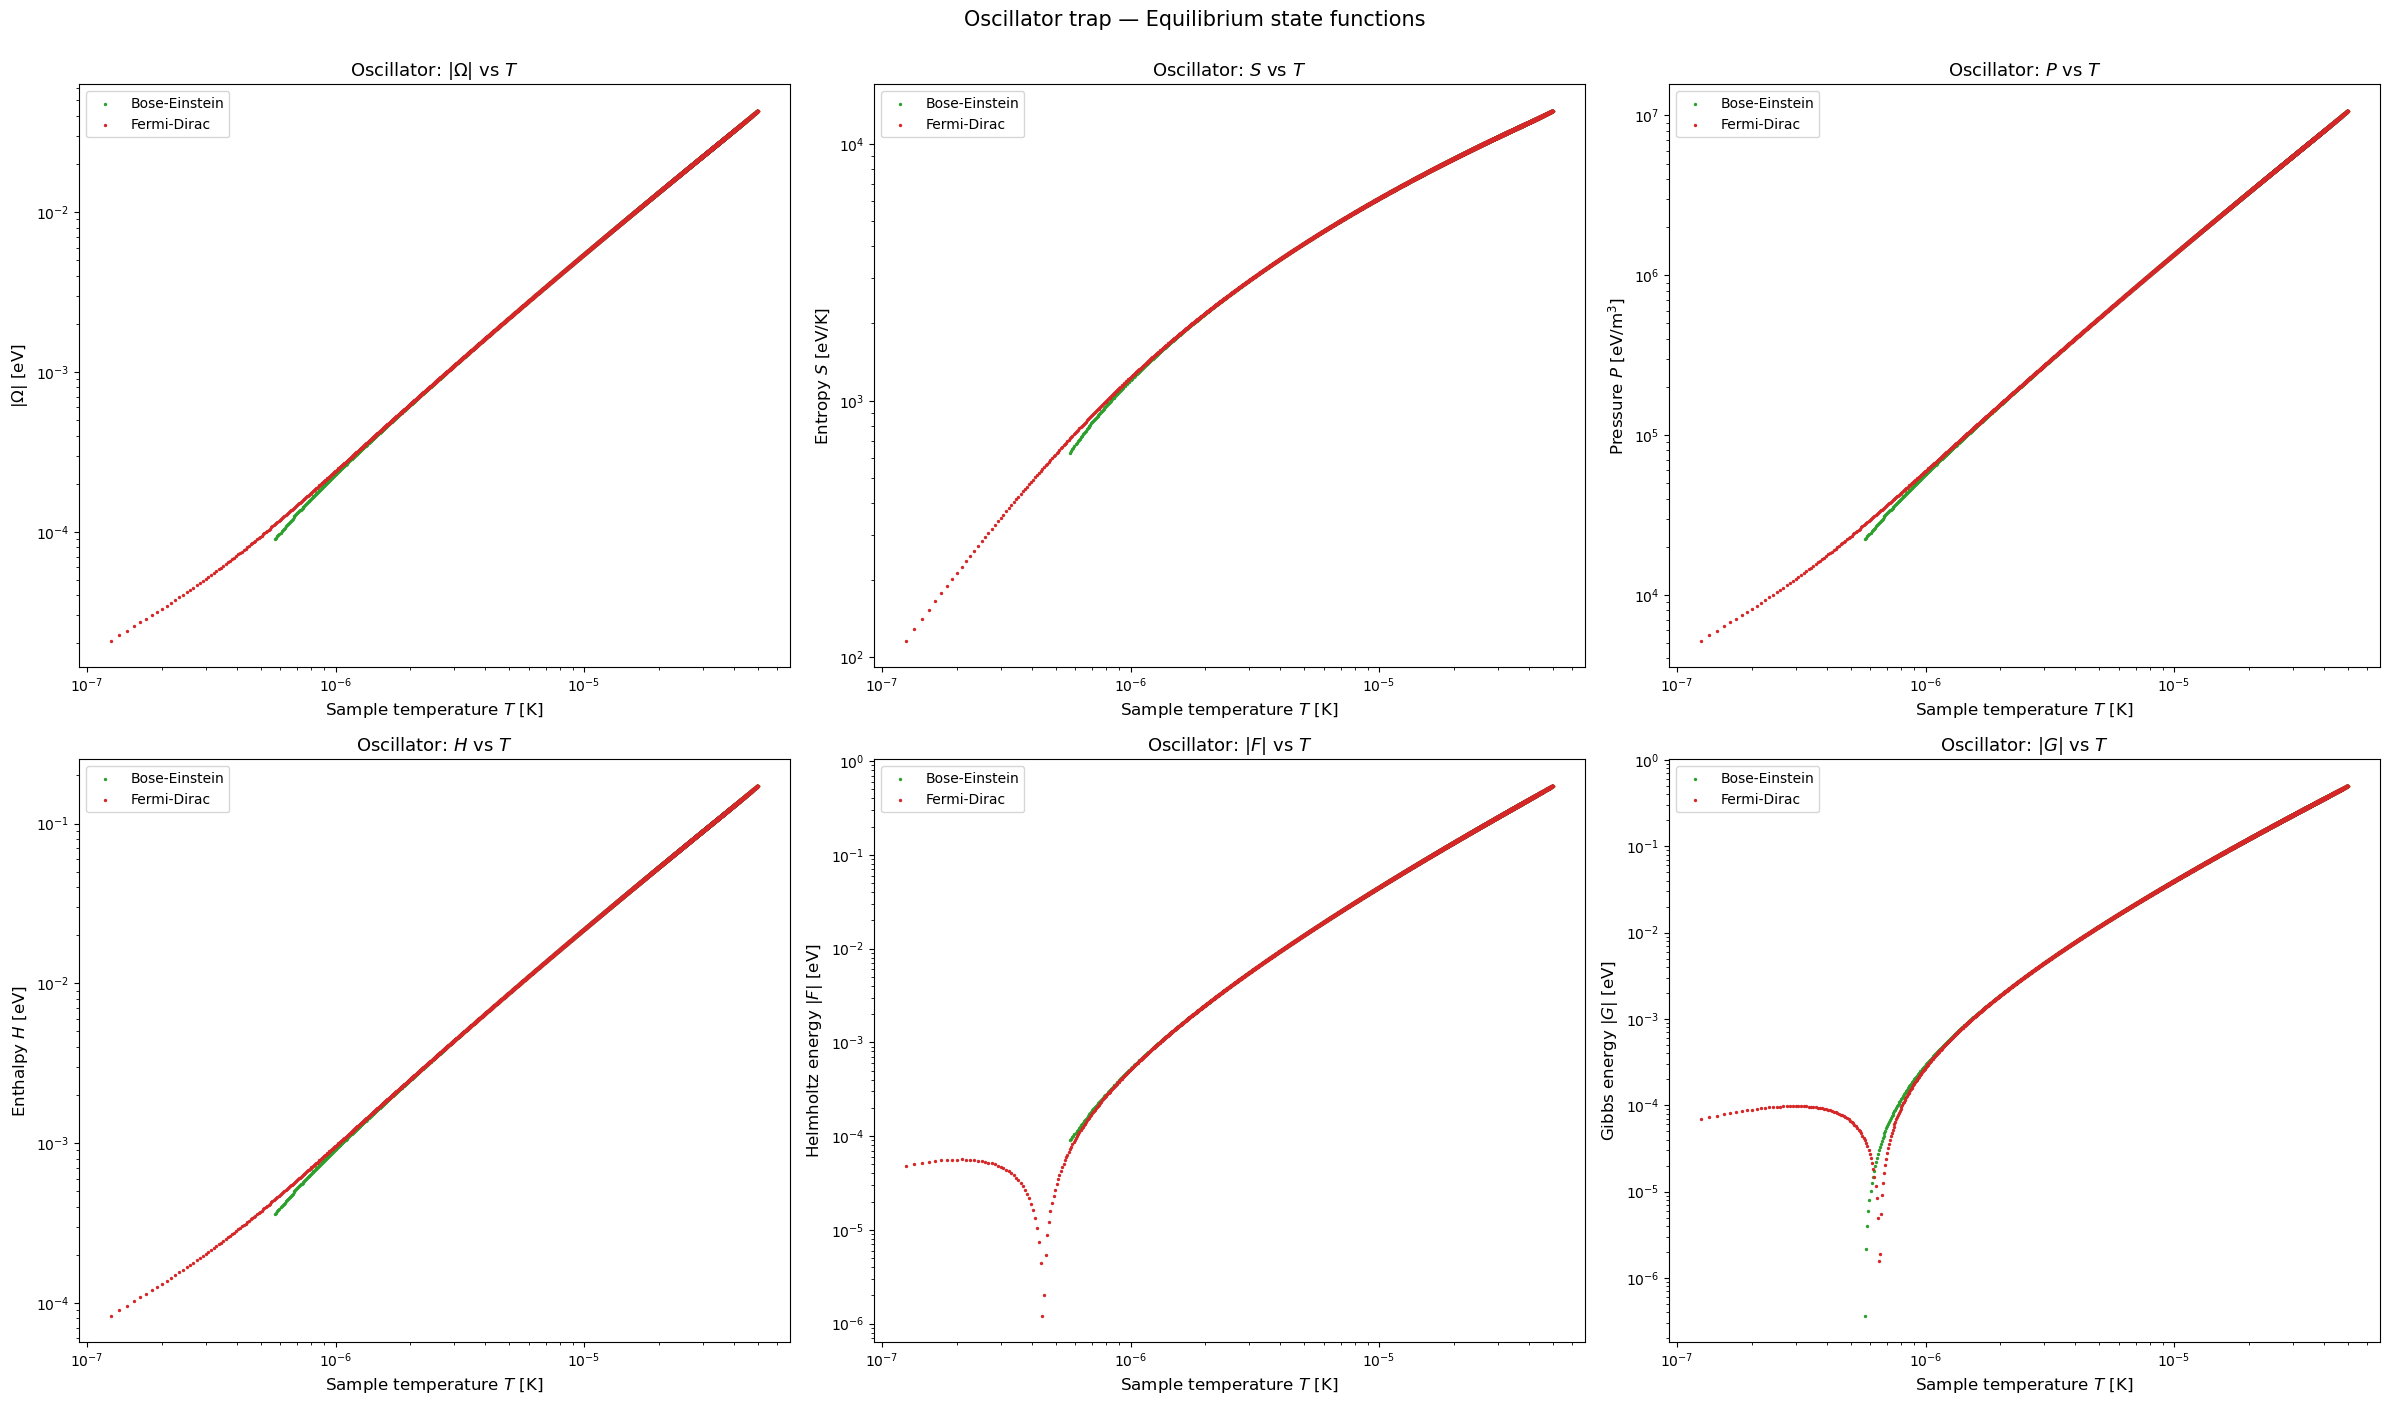

In [8]:
data = load_thermo_pair(session, "oscillator")
if data is not None:
    T_b, thermo_b, T_f, thermo_f = data
    fig_osc_state = plot_state_functions(
        T_b, thermo_b, T_f, thermo_f,
        trap_name="Oscillator",
        units_energy=units_for("oscillator"),
    )
    plt.show()


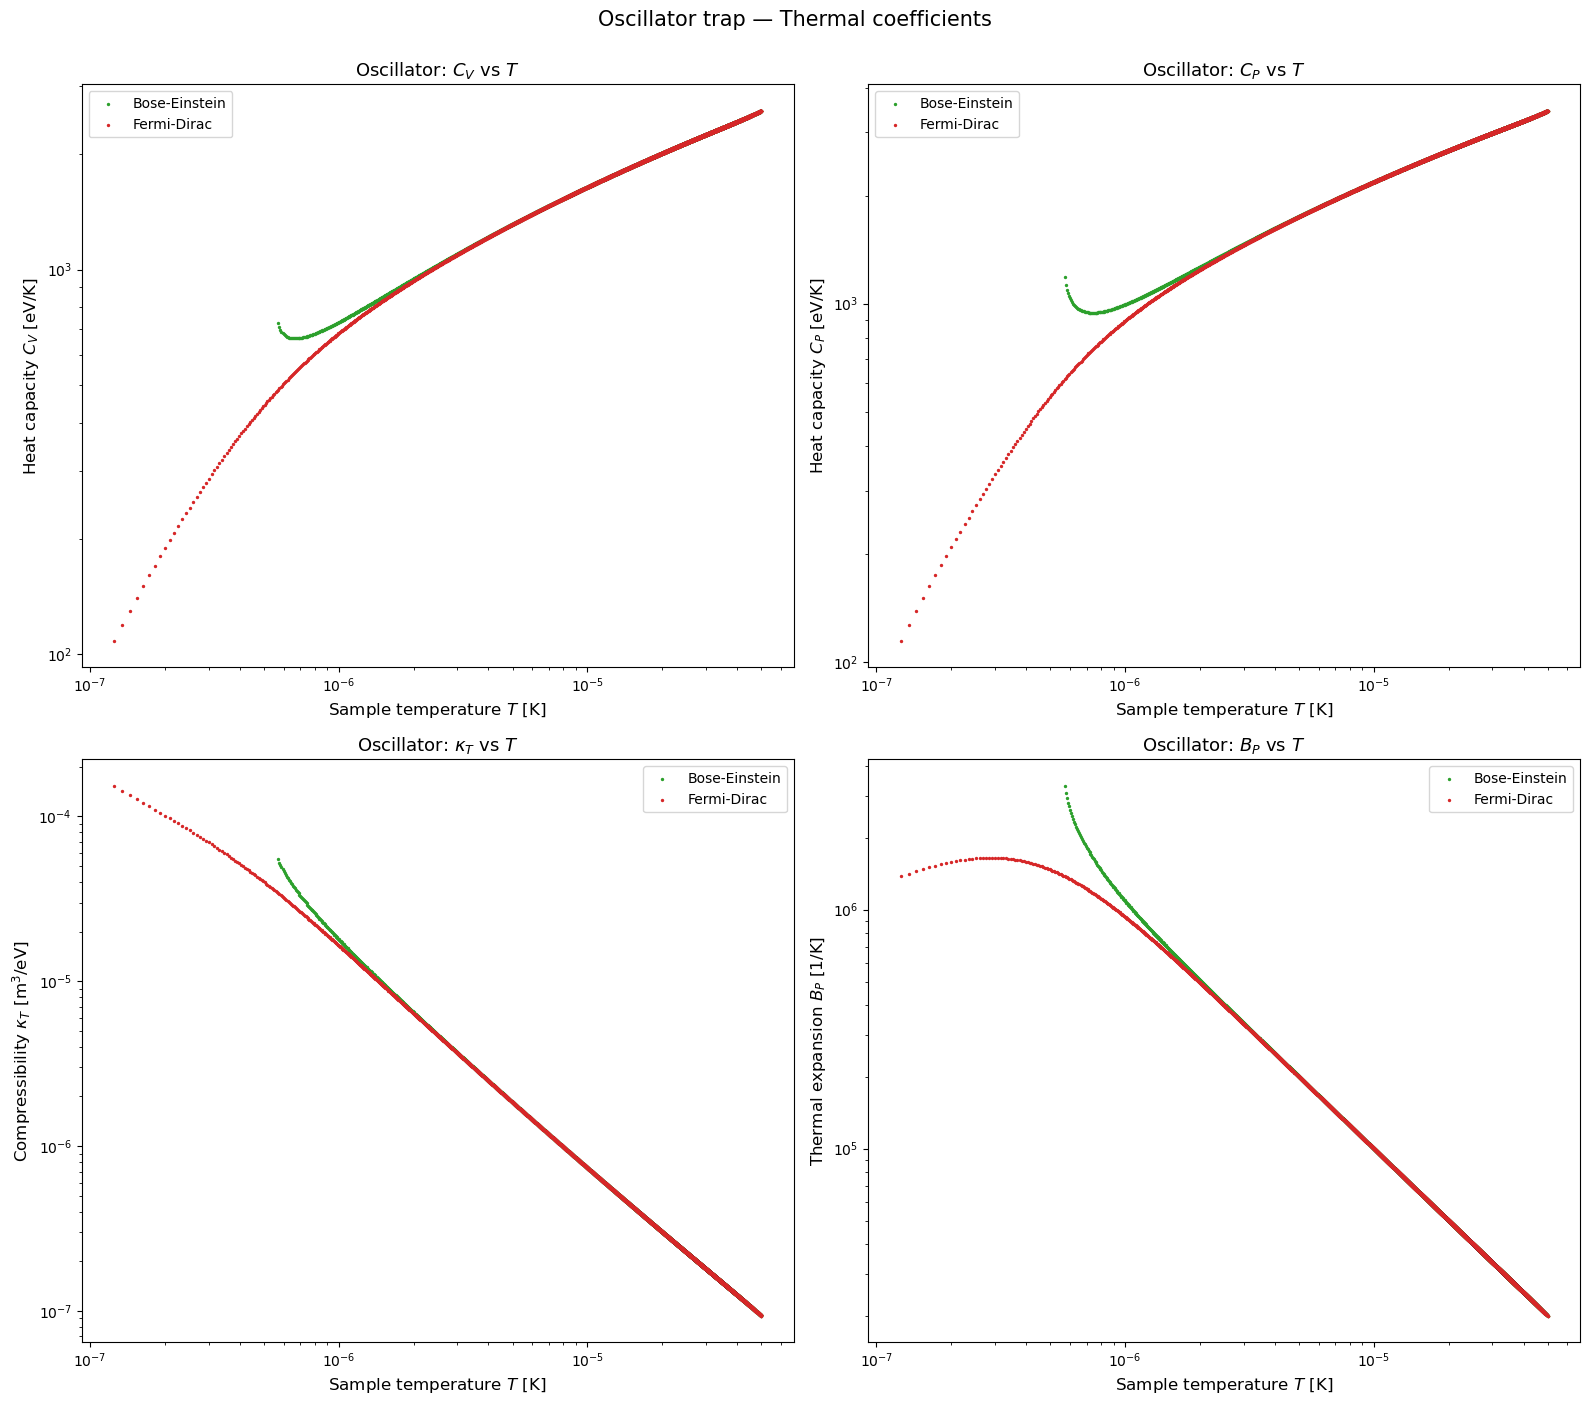

In [9]:
if data is not None:
    fig_osc_coef = plot_thermal_coefficients(
        T_b, thermo_b, T_f, thermo_f,
        trap_name="Oscillator",
        units_energy=units_for("oscillator"),
    )
    plt.show()


## 4. Reading the figures

A few things worth noting on the plots:

- **Sign convention.** $\Omega = -PV$ is always negative. $F = G + \Omega$
  and $G = \mu N$ change sign with the regime ($\mu < 0$ for bosons in
  the non-degenerate limit; fermions can have $\mu > 0$). With the
  default `log_y=True`, all three are shown as $|\cdot|$. Pass
  `log_y=False` to either plot function to see signed values on a linear
  axis.

- **Bosons vs fermions.** Within a single panel, the green/red ordering
  reflects how the polylog $g_s(\alpha)$ differs between BE and FD at
  the same $(N, T)$. The gap typically widens as $T$ drops, mirroring
  the onset of degeneracy.

- **Scaling sanity check.** For pure-geometry traps in equilibrium,
  $\Omega = -E/s$. If the polylog evaluation in `equilibrium.py` and
  the saved $E$ disagree, $|\Omega|$ on the first panel will not lie on
  a clean power law in $T$ — the cheapest visual check that the
  rethermalisation Newton-Raphson converged at every step.

- **Heat-capacity ratio.** $C_P > C_V$ is required by stability; the
  two should track each other on the coefficients plot. A panel where
  $C_P$ falls below $C_V$ is a numerical artefact (typically near a
  degeneracy boundary where $\kappa_T$ or $B_P$ blow up).

## 5. Tweaks

- `log_x=False` / `log_y=False` for linear axes (signed values, no abs).
- `n_b`, `n_f` to trim the trajectory if you want to exclude the early
  (high-$T$, weakly-degenerate) or late (near-halt) parts.
- `figsize=(W, H)` to resize.
- `units_energy="..."` if you've built a trap with a custom unit system.
